In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Diabetic retinopathy.zip"
extract_path = "/content/diabetic_retinopathy_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")


Dataset extracted successfully!


In [3]:
image_extensions = ('.jpg', '.jpeg', '.png')

total_images = 0

for root, dirs, files in os.walk(extract_path):
    total_images += len([f for f in files if f.lower().endswith(image_extensions)])

print("Total images in dataset:", total_images)


Total images in dataset: 5676


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam




In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

def _class_names_from_generator(generator):
    """Return class names ordered by their integer indices."""
    idx_to_class = {v: k for k, v in generator.class_indices.items()}
    return [idx_to_class[i] for i in range(len(idx_to_class))]



    if normalize:
        row_sums = cm_plot.sum(axis=1, keepdims=True)
        cm_plot = np.divide(cm_plot, row_sums, out=np.zeros_like(cm_plot), where=row_sums != 0)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_plot, interpolation='nearest')
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel='True label',
        xlabel='Predicted label',
        title=title + (' (Normalized)' if normalize else ''),
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    fmt = '.2f' if normalize else '.0f'
    thresh = cm_plot.max() / 2.0 if cm_plot.size else 0
    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            ax.text(
                j,
                i,
                format(cm_plot[i, j], fmt),
                ha='center',
                va='center',
                color='white' if cm_plot[i, j] > thresh else 'black',
            )

    fig.tight_layout()
    plt.show()

def evaluate_model_on_generator(
    model,
    generator,
    is_binary,
    threshold=0.5,
    plot=True,
    plot_normalized=True,
    show_report_table=True,
):

    generator.reset()
    y_true = generator.classes
    steps = int(np.ceil(generator.samples / generator.batch_size))

    y_prob = model.predict(generator, steps=steps, verbose=1)

    if is_binary:
        y_prob = np.asarray(y_prob).ravel()
        y_pred = (y_prob >= threshold).astype(int)
        labels = [0, 1]
        avg = 'binary'
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
    else:
        y_pred = np.argmax(y_prob, axis=1)
        labels = list(range(generator.num_classes))
        avg = 'macro'
        precision = precision_score(y_true, y_pred, average=avg, zero_division=0)
        recall = recall_score(y_true, y_pred, average=avg, zero_division=0)
        f1 = f1_score(y_true, y_pred, average=avg, zero_division=0)

    accuracy = accuracy_score(y_true, y_pred)

    class_names = _class_names_from_generator(generator)

    print('Class index mapping:', generator.class_indices)


    report_str = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
    print('\nClassification Report:\n', report_str)

    print(f'Accuracy:  {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall:    {recall:.4f}')
    print(f'F1 score:  {f1:.4f}')

    report_df = None
    if show_report_table:
        report_dict = classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )
        report_df = pd.DataFrame(report_dict).transpose()
        display(report_df)



    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'class_names': class_names,
        'report_df': report_df,
    }

In [6]:
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
EPOCHS = 20

train_dir = extract_path + "/Diagnosis of Diabetic Retinopathy/train"
valid_dir=  extract_path + "/Diagnosis of Diabetic Retinopathy/valid"
test_dir  = extract_path + "/Diagnosis of Diabetic Retinopathy/test"

**Inception V3**

In [7]:
import tensorflow.keras.backend as K
K.clear_session()

from tensorflow.keras.applications import InceptionV3

**Data Generators**

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = test_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 2076 images belonging to 2 classes.
Found 531 images belonging to 2 classes.
Found 231 images belonging to 2 classes.


**Load Pretrained Model**

In [ ]:
Inception_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(299, 299, 3)
)


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Fine-tuning the Last 50 Layers of InceptionV3**

In [ ]:
for layer in Inception_model.layers[:-50]:  # unfreeze last 50 layers
    layer.trainable = False

for layer in Inception_model.layers[-50:]:
    layer.trainable = True

**Add Custom Layers**

In [ ]:
x = Inception_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model_inception = Model(inputs=Inception_model.input, outputs=output)

**Compile Model**

In [ ]:
model_inception.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

**Train Model by Callback**

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

model_path = '/content/drive/MyDrive/Call back Model/DR_InceptionV3.h5'

checkpoint = ModelCheckpoint(
    model_path,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

callbacks_list = [checkpoint, early_stopping]


# TRAIN MODEL

history_inception = model_inception.fit(
    train_data,
    epochs=20,
    verbose=1,
    validation_data=val_data,
    callbacks=callbacks_list
)

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 988ms/step - accuracy: 0.6583 - loss: 0.6145
Epoch 1: val_accuracy improved from None to 0.73635, saving model to /content/drive/MyDrive/Call back Model/DR_InceptionV3.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Call back Model/DR_InceptionV3.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.7741 - loss: 0.5023 - val_accuracy: 0.7363 - val_loss: 0.4783
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.8822 - loss: 0.3039
Epoch 2: val_accuracy improved from 0.73635 to 0.84934, saving model to /content/drive/MyDrive/Call back Model/DR_InceptionV3.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Call back Model/DR_InceptionV3.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 55s 845ms/step - accuracy: 0.8998 - loss: 0.2737 - val_accuracy: 0.8493 - val_loss: 0.3292
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 739ms/step - accuracy: 0.9072 - loss: 0.2457
Epoch 3: val_accuracy improved from 0.84934 to 0.91337, saving model to /content/drive/MyDrive/Call back Model/DR_InceptionV3.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Call back Model/DR_InceptionV3.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 54s 829ms/step - accuracy: 0.9191 - loss: 0.2263 - val_accuracy: 0.9134 - val_loss: 0.2150
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 752ms/step - accuracy: 0.9309 - loss: 0.1979
Epoch 4: val_accuracy improved from 0.91337 to 0.94350, saving model to /content/drive/MyDrive/Call back Model/DR_InceptionV3.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Call back Model/DR_InceptionV3.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 55s 833ms/step - accuracy: 0.9364 - loss: 0.1943 - val_accuracy: 0.9435 - val_loss: 0.1636
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.9474 - loss: 0.1710
Epoch 5: val_accuracy improved from 0.94350 to 0.95104, saving model to /content/drive/MyDrive/Call back Model/DR_InceptionV3.h5



Epoch 5: finished saving model to /content/drive/MyDrive/Call back Model/DR_InceptionV3.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 55s 855ms/step - accuracy: 0.9489 - loss: 0.1645 - val_accuracy: 0.9510 - val_loss: 0.1440
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.9538 - loss: 0.1346
Epoch 6: val_accuracy improved from 0.95104 to 0.96045, saving model to /content/drive/MyDrive/Call back Model/DR_InceptionV3.h5



Epoch 6: finished saving model to /content/drive/MyDrive/Call back Model/DR_InceptionV3.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 55s 843ms/step - accuracy: 0.9523 - loss: 0.1444 - val_accuracy: 0.9605 - val_loss: 0.1255
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 746ms/step - accuracy: 0.9586 - loss: 0.1296
Epoch 7: val_accuracy did not improve from 0.96045
65/65 ━━━━━━━━━━━━━━━━━━━━ 51s 778ms/step - accuracy: 0.9562 - loss: 0.1324 - val_accuracy: 0.9567 - val_loss: 0.1260
Epoch 8/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.9705 - loss: 0.1108
Epoch 8: val_accuracy did not improve from 0.96045
65/65 ━━━━━━━━━━━━━━━━━━━━ 49s 743ms/step - accuracy: 0.9648 - loss: 0.1216 - val_accuracy: 0.9605 - val_loss: 0.1162
Epoch 9/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - accuracy: 0.9636 - loss: 0.1130
Epoch 9: val_accuracy did not improve from 0.96045
65/65 ━━━━━━━━━━━━━━━━━━━━ 47s 730ms/step - accuracy: 0.9639 - loss: 0.1128 - val_accuracy: 0.9605 - val_loss: 0.1138
Epoch 10/20
65/65 ━━━━━━━


Epoch 11: finished saving model to /content/drive/MyDrive/Call back Model/DR_InceptionV3.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 52s 789ms/step - accuracy: 0.9668 - loss: 0.1059 - val_accuracy: 0.9680 - val_loss: 0.0990
Epoch 12/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.9738 - loss: 0.0807
Epoch 12: val_accuracy did not improve from 0.96798
65/65 ━━━━━━━━━━━━━━━━━━━━ 52s 798ms/step - accuracy: 0.9716 - loss: 0.0911 - val_accuracy: 0.9661 - val_loss: 0.0985
Epoch 13/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.9693 - loss: 0.0934
Epoch 13: val_accuracy did not improve from 0.96798
65/65 ━━━━━━━━━━━━━━━━━━━━ 48s 732ms/step - accuracy: 0.9706 - loss: 0.0900 - val_accuracy: 0.9623 - val_loss: 0.0975
Epoch 14/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - accuracy: 0.9767 - loss: 0.0758
Epoch 14: val_accuracy did not improve from 0.96798
65/65 ━━━━━━━━━━━━━━━━━━━━ 47s 722ms/step - accuracy: 0.9706 - loss: 0.0881 - val_accuracy: 0.9661 - val_loss: 0.0933
Epoch 15/20
65/65 

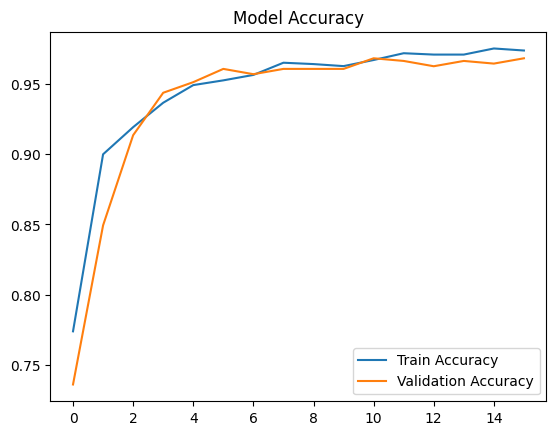

In [ ]:
plt.plot(history_inception.history['accuracy'], label='Train Accuracy')
plt.plot(history_inception.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

**Load Save Model**

In [9]:
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np
from tensorflow import keras
from tensorflow.keras.preprocessing import image

model_path = '/content/drive/MyDrive/Call back Model/DR_InceptionV3.h5'
model1 = keras.models.load_model(model_path)

**Predict Images with Diabetic Retinipathy Disease**

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
img2.jpg → Prediction: 0.000598 → DR (Class 0)


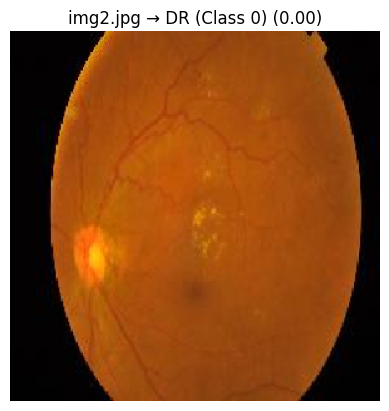

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
img4.jpg → Prediction: 0.173990 → DR (Class 0)


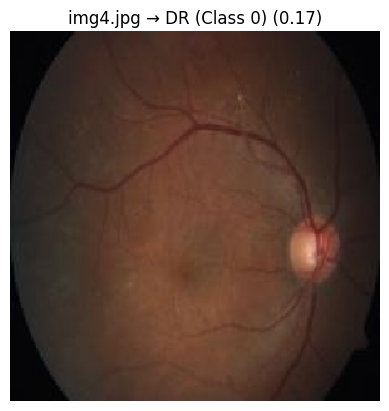

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
img1.jpg → Prediction: 0.017979 → DR (Class 0)


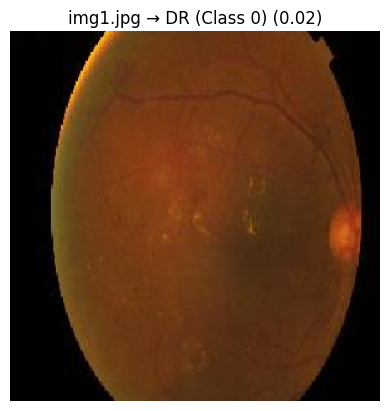

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
img8.png → Prediction: 0.006998 → DR (Class 0)


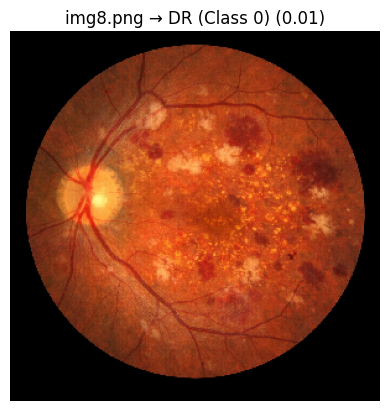

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
img6.jpg → Prediction: 0.008905 → DR (Class 0)


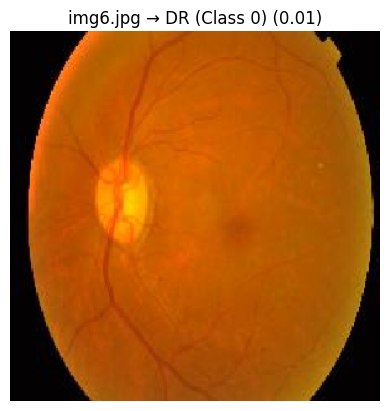

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
img3.jpg → Prediction: 0.007215 → DR (Class 0)


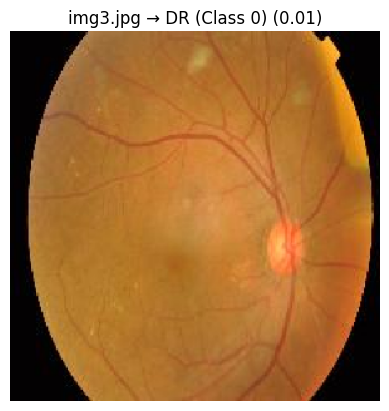

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
img5.jpg → Prediction: 0.005655 → DR (Class 0)


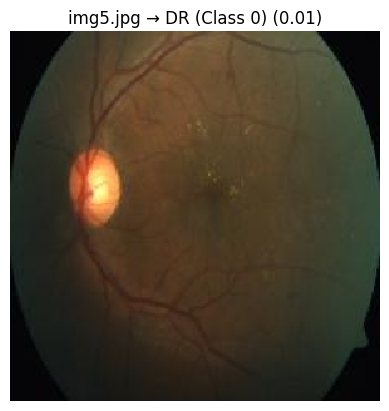

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
img7.jpg → Prediction: 0.021057 → DR (Class 0)


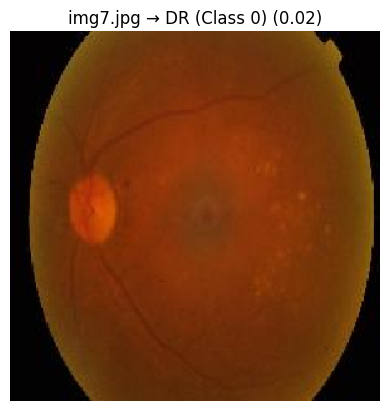

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

folder_path = '/content/drive/MyDrive/DR images'
valid_ext = ('.jpg', '.jpeg', '.png')

for img_name in os.listdir(folder_path):
    img_path = os.path.join(folder_path, img_name)

    if not img_name.lower().endswith(valid_ext):
        continue

    # Load and preprocess image
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img) / 255.0
    img_array_exp = np.expand_dims(img_array, axis=0)

    # Predict
    pred = model1.predict(img_array_exp)[0][0]

    # Determine class label
    if pred < 0.5:
        class_label = "DR (Class 0)"
    else:
        class_label = "No DR (Class 1)"

    # Print prediction in console
    print(f"{img_name} → Prediction: {pred:.6f} → {class_label}")

    # Show image with prediction as title
    plt.imshow(img)
    plt.title(f"{img_name} → {class_label} ({pred:.2f})")
    plt.axis('off')
    plt.show()

**Predict Images with No Diabetic Retinipathy Disease**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
dr3.jpg → Prediction: 0.995534 → No DR (Class 1)


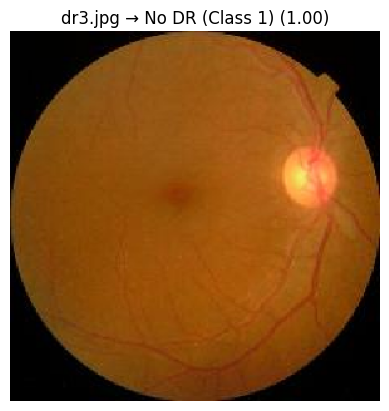

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
dr1.jpg → Prediction: 0.993700 → No DR (Class 1)


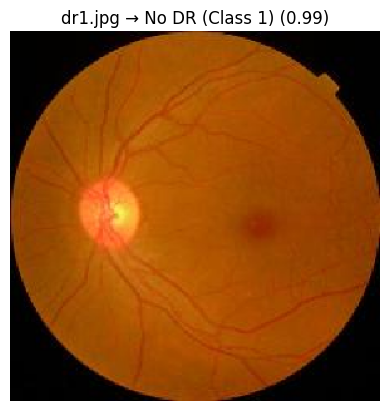

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
dr2.jpg → Prediction: 0.972565 → No DR (Class 1)


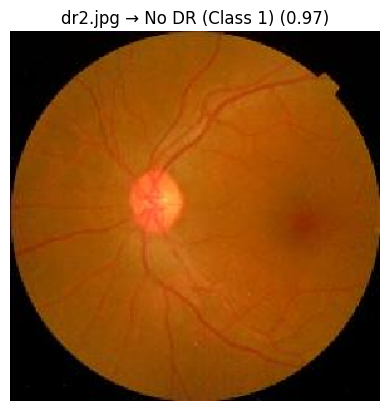

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
dr5.jpg → Prediction: 0.996117 → No DR (Class 1)


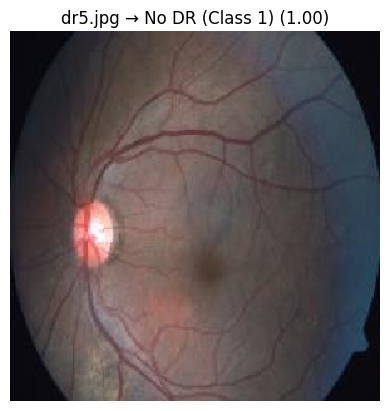

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
dr4.jpg → Prediction: 0.991237 → No DR (Class 1)


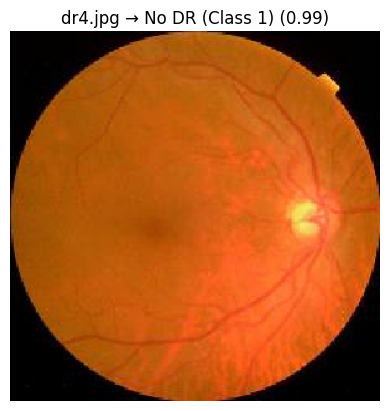

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

folder_path = '/content/drive/MyDrive/No DR Images'
valid_ext = ('.jpg', '.jpeg', '.png')

for img_name in os.listdir(folder_path):
    img_path = os.path.join(folder_path, img_name)

    if not img_name.lower().endswith(valid_ext):
        continue

    # Load and preprocess image
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img) / 255.0
    img_array_exp = np.expand_dims(img_array, axis=0)

    # Predict
    pred = model1.predict(img_array_exp)[0][0]

    # Determine class label
    if pred < 0.5:
        class_label = "DR (Class 0)"
    else:
        class_label = "No DR (Class 1)"

    # Print prediction in console
    print(f"{img_name} → Prediction: {pred:.6f} → {class_label}")

    # Show image with prediction as title
    plt.imshow(img)
    plt.title(f"{img_name} → {class_label} ({pred:.2f})")
    plt.axis('off')
    plt.show()

**Classification Report**

In [10]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 231 images belonging to 2 classes.


In [11]:
# Predictions
y_pred_probs = model1.predict(test_generator)

# Convert probabilities to 0/1
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step


In [12]:
y_true = test_generator.classes

In [13]:
from sklearn.metrics import classification_report

class_labels = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_labels))

              precision    recall  f1-score   support

          DR       0.99      0.96      0.97       113
       No_DR       0.96      0.99      0.97       118

    accuracy                           0.97       231
   macro avg       0.97      0.97      0.97       231
weighted avg       0.97      0.97      0.97       231



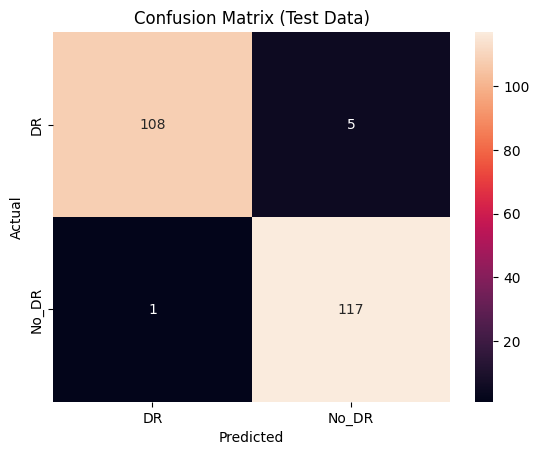

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Data)")
plt.show()